# LLM · 11 — SwiGLU: let the gate be a matrix

`10` left off on a specific complaint. Swish is a **value** multiplied by a **gate**:

```-
Swish(x) = x · sigmoid(beta * x)
           ^         ^
           value     gate — a FIXED function of the value itself
```

The gate's *sharpness* is tunable — we even made `beta` learnable and watched the model
climb it. But **what the gate looks at** is not: it can only ever look at `x`. `11` asks
the obvious next question. What if the gate got its **own matrix**?

```-
GLU(x)    = (W·x + b) ⊗ sigmoid(V·x + c)     # gate = a separate learned projection
SwiGLU(x) = (W·x + b) ⊗ Swish(V·x + c)       # ...with Swish as the gate instead
```

That's a **GLU** (Dauphin 2017), and with Swish in it, **SwiGLU** (Shazeer 2020) — what
Llama, PaLM, Mistral and Qwen run instead of `06`'s FeedForward. It costs a third
matrix, so the honest comparison has to hold parameters equal, which is where the famous
`8C/3` hidden size comes from.

Here's what the measurements did to my expectations.

- **the activation is no longer the nonlinearity — the product is.** `10`'s headline was
  that deleting the FFN's activation *destroys* it: two stacked `Linear`s are one
  `Linear`, so the whole `4x` layer collapses to a matrix. Do the same thing to a GLU —
  delete the activation entirely, leaving `(W·x) ⊗ (V·x)`, a **bilinear** layer with no
  activation function anywhere in it — and it **does not collapse**. It lands level
  with `06`'s GELU FFN. A product is not a sum; `10`'s fusion argument doesn't apply.
- **so the experiment is a 2x2, not an A/B.** Gate and activation are two independent
  nonlinearities, and the grid is the most informative thing in this notebook: **either
  one alone lands in the same place**, and **both together** beat either.
- **which explains a puzzle `10` set up.** `10` found the activation choice mattered a
  lot — SiLU lost to GELU well outside seed noise, and sigmoid/tanh were disasters.
  Inside a GLU, that whole ranking **evaporates**: SwiGLU, GEGLU and ReGLU land on top
  of each other. Shazeer famously declined to explain this. The 2x2 explains it — once
  the product supplies the nonlinearity, the activation stops being load-bearing.
- **and the mechanism is one line of algebra.** `Swish(x) ≈ 0.5x + (beta/4)x²` — its
  nonlinear term is a *vanishing fraction* of the output as the input scale drops, which
  is exactly how `10`'s deep blocks slid into the linear regime. A product `(Wx)⊗(Vx)`
  is **degree-2 homogeneous**: scale the input by `s` and the output scales by `s²`,
  with the nonlinear fraction **unchanged**. We measure this and it's flat at 99.6%
  across a 100x range of input scales. It *cannot* linearize. That's the whole ballgame.
- **my tidy explanation for it died anyway.** I predicted the gate's own matrix would
  let it run *sharper* than `10`'s FFN could. It doesn't — it runs at `s ≈ 1.4`, `10`'s
  **soft** end, and wins regardless. What actually disappears is the *depth collapse*.

> Shazeer, *GLU Variants Improve Transformer* (2020), on why they work:
> "We offer no explanation as to why these architectures seem to work; we attribute
> their success, as all else, to divine benevolence."
> We can't fully explain it either — but the 2x2 gets further than the paper does.

In [1]:
from pathlib import Path

import math
import time

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F


def _repo_root() -> Path:
    """Walk up from the cwd to the folder holding pyproject.toml, so paths work no
    matter where the kernel is launched from."""
    here = Path.cwd()
    for d in (here, *here.parents):
        if (d / "pyproject.toml").exists():
            return d
    return here


ROOT = _repo_root()
DATA = ROOT / "nb" / "llm" / "data" / "input.txt"  # tinyshakespeare, shared with 01–10
DEV = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(1337)

# This notebook trains ~23 models, so buy back the time: let float32 matmuls use
# TF32 tensor cores (~1.4x here). It costs mantissa bits in the matmuls only —
# the fusion/homogeneity proofs below are CPU least-squares and are unaffected.
torch.set_float32_matmul_precision("high")
print(f"device: {DEV}")

device: cuda


## Same data skeleton as `03`–`10`

In [2]:
text = DATA.read_text()
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for i, c in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: "".join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

BLOCK = 64
BATCH = 32
EMBD = 128


def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - BLOCK, (BATCH,))
    x = torch.stack([d[i:i + BLOCK] for i in ix])
    y = torch.stack([d[i + 1:i + 1 + BLOCK] for i in ix])
    return x.to(DEV), y.to(DEV)


print(f"corpus {len(text):,} chars, vocab {vocab_size}, block {BLOCK}")

corpus 1,115,394 chars, vocab 65, block 64


## The two feed-forwards

`06`'s FFN and the GLU, side by side. The diff is the notebook: the GLU splits the
input into **two** projections and multiplies them elementwise, instead of running one
projection through a fixed curve.

```-
FFN(x)  = proj( act( fc(x) ) )                 2 matrices: C→H, H→C
GLU(x)  = proj( up(x)  ⊗  act( gate(x) ) )     3 matrices: C→H, C→H, H→C
                 └value┘    └── gate ──┘
```

Note what `act` is doing in each. In the FFN it's the *only* nonlinearity, sitting on
the critical path. In the GLU it shapes **one branch of a product** — and the product is
already nonlinear without it. That relocation is the entire lesson, so the GLU's `act`
defaults to `Identity`: we want the version with **no activation function at all** to be
the natural starting point, not an exotic ablation.

In [3]:
class FeedForward(nn.Module):
    """06's FFN: expand to `hidden`, one fixed nonlinearity, project back."""

    def __init__(self, n_embd, hidden=None, act=None):
        super().__init__()
        hidden = hidden or 4 * n_embd
        self.fc = nn.Linear(n_embd, hidden)
        self.proj = nn.Linear(hidden, n_embd)
        self.proj.RESIDUAL_PROJ = True
        self.act = act if act is not None else nn.GELU()

    def forward(self, x):
        return self.proj(self.act(self.fc(x)))


class GLUFeedForward(nn.Module):
    """Gated FFN: two projections multiplied elementwise, then projected back.

    act=Identity -> a BILINEAR layer: no activation function anywhere in it.
    act=SiLU     -> SwiGLU (Llama).   act=GELU -> GEGLU.   act=ReLU -> ReGLU.
    """

    def __init__(self, n_embd, hidden, act=None, bias=True):
        super().__init__()
        self.up = nn.Linear(n_embd, hidden, bias=bias)      # the value branch
        self.gate = nn.Linear(n_embd, hidden, bias=bias)    # the gate branch
        self.proj = nn.Linear(hidden, n_embd, bias=bias)
        self.proj.RESIDUAL_PROJ = True
        self.act = act if act is not None else nn.Identity()

    def forward(self, x):
        return self.proj(self.up(x) * self.act(self.gate(x)))

## `10`'s collapse argument, and why it stops at the product

This is the hinge of the notebook, so it's worth being slow.

`10` proved: *without an activation, `Linear → Linear` is one `Linear`* —
`W2(W1x + b1) + b2 = (W2W1)x + (W2b1 + b2)`. Depth in a stack of linear maps buys
nothing, so the FFN's `4x` hidden layer is decoration and the layer stops existing.

Now try to run that argument on a bilinear GLU, `proj(up(x) ⊗ gate(x))`, and it fails
at the first step. `W2W1` worked because **composition** of linear maps is linear.
`up(x) ⊗ gate(x)` is not a composition — it's a **product of two outputs**. Multiply two
things that are each linear in `x` and you get something *quadratic* in `x`:

```-
(w·x)(v·x) = sum_ij w_i v_j x_i x_j        <- every pairwise product of input features
```

There is no matrix `M` with `Mx = (w·x)(v·x)`, because the left side is degree 1 in `x`
and the right side is degree 2. So the GLU has a genuine nonlinearity **built out of
nothing but `Linear` layers**. The fixed curve was never the only way to get one.

The sharpest way to see this: `10` fused its activation-less FFN into a single `Linear`
and matched to ~0. Try the same fusion on a bilinear layer and ask how much of it a
`Linear` can capture *at best* — via least squares, which finds the optimal one.

In [4]:
CF, HF = 8, 32
xs_lin = torch.randn(4096, CF)


class Bilinear(nn.Module):
    """(W·x) ⊗ (V·x) → proj. No activation function anywhere."""

    def __init__(self, cin, hidden, cout, bias=False):
        super().__init__()
        self.up = nn.Linear(cin, hidden, bias=bias)
        self.gate = nn.Linear(cin, hidden, bias=bias)
        self.proj = nn.Linear(hidden, cout, bias=bias)

    def forward(self, x):
        return self.proj(self.up(x) * self.gate(x))


torch.manual_seed(0)
bil = Bilinear(CF, HF, CF)
ffn_noact = nn.Sequential(nn.Linear(CF, HF, bias=False), nn.Linear(HF, CF, bias=False))


def best_linear_residual(f):
    """Fit the BEST possible single Linear to f by least squares; return relative error.
    ~0 means 'f was secretly a Linear all along' (10's collapse)."""
    with torch.no_grad():
        y = f(xs_lin)
    w = torch.linalg.lstsq(xs_lin, y).solution
    return ((xs_lin @ w - y).norm() / y.norm()).item()


print("How well can ONE Linear reproduce this layer? (least-squares best case)")
print(f"  FFN, no activation (10's) : {best_linear_residual(ffn_noact):.2e} relative "
      f"error  <- it IS a Linear")
print(f"  bilinear GLU, no activation: {best_linear_residual(bil):>8.1%} relative error"
      f"  <- a Linear cannot touch it")
print("\nSame 'no activation function' ablation, opposite outcome. The product is the")
print("nonlinearity, so deleting the activation doesn't delete the layer.")

How well can ONE Linear reproduce this layer? (least-squares best case)
  FFN, no activation (10's) : 7.06e-07 relative error  <- it IS a Linear
  bilinear GLU, no activation:    99.9% relative error  <- a Linear cannot touch it

Same 'no activation function' ablation, opposite outcome. The product is the
nonlinearity, so deleting the activation doesn't delete the layer.


### It's *quadratic*, and you can read that off its scaling

`09` identified RMSNorm by a scaling law — `RMSNorm(2x) == RMSNorm(x)`, an invariance no
matrix can fake. The bilinear layer has its own signature, and it's just as diagnostic.
With no biases, every term is a product of exactly two linear factors, so scaling the
input by `s` scales the output by `s²`:

```-
bilinear(s·x) == s² · bilinear(x)        # degree-2 homogeneous
Linear(s·x)   == s  · Linear(x)          # degree-1 — that's what linear means
```

Degree 2, not degree 1. That single exponent is the proof it isn't a linear map, and —
as the next section shows — it's also the reason SwiGLU behaves so differently from
`10`'s FFN.

In [5]:
x_h = torch.randn(5, CF)
for s in (2.0, 3.0):
    lhs, rhs = bil(s * x_h), s ** 2 * bil(x_h)
    print(f"bilinear({s}x) == {s}^2 · bilinear(x)? "
          f"{torch.allclose(lhs, rhs, atol=1e-5)}   "
          f"max diff {(lhs - rhs).abs().max():.2e}")
gap = (bil(2 * x_h) - 2 * bil(x_h)).abs().max()
print(f"bilinear(2x) == 2 · bilinear(x)?   False  (off by {gap:.3f})  <- NOT linear")

bilinear(2.0x) == 2.0^2 · bilinear(x)? True   max diff 0.00e+00
bilinear(3.0x) == 3.0^2 · bilinear(x)? True   max diff 9.54e-07
bilinear(2x) == 2 · bilinear(x)?   False  (off by 1.080)  <- NOT linear


## The mechanism: a product cannot linearize

Now the payoff, and it's the idea I'd most want you to keep.

`10` ended on a worry it couldn't fix. `Swish(x) ≈ 0.5x + (beta/4)x²` near zero: a
**linear** term plus a **nonlinear** term. As the input scale falls, the `x²` term dies
*quadratically* while the `0.5x` term dies only *linearly* — so the nonlinear part
becomes a vanishing **fraction** of the output. A Swish fed small inputs is a straight
line. That's precisely what `10` caught happening with depth: plain SiLU's effective
scale ran `[2.1, 2.1, 1.0, 0.3]`, and by the last block the FFN was doing nearly
nothing.

A product has no such failure mode, and the homogeneity above is why. Scale the input by
`s`: **every** term is degree 2, so the whole output scales by `s²` and the *ratio* of
nonlinear to linear content doesn't move. There is no small-input regime where a
bilinear layer starts looking like a matrix.

That's a claim we can measure rather than assert. For each layer, fit the best
**affine** map to it (least squares, bias allowed) and report the fraction of the
output's variance that fit **cannot** explain — call it the *nonlinear fraction*. Sweep
the input scale:

In [6]:
def nonlinear_fraction(f, s, cin, n=8192):
    """Fraction of f's output variance that no affine map can explain, at input scale s.
    0 = f is a linear map here. 1 = a linear map explains nothing about f."""
    x = torch.randn(n, cin) * s
    with torch.no_grad():
        y = f(x)
    xa = torch.cat([x, torch.ones(n, 1)], dim=1)          # affine: allow a bias column
    sol = torch.linalg.lstsq(xa, y).solution
    resid = y - xa @ sol
    return (resid.norm() / (y - y.mean(0)).norm()).item()


CM, HM = 64, 256


class GLUProbe(nn.Module):
    def __init__(self, act=None, bias=True):
        super().__init__()
        self.up = nn.Linear(CM, HM, bias=bias)
        self.gate = nn.Linear(CM, HM, bias=bias)
        self.proj = nn.Linear(HM, CM, bias=bias)
        self.act = act or nn.Identity()

    def forward(self, x):
        return self.proj(self.up(x) * self.act(self.gate(x)))


torch.manual_seed(0)
probes = [
    ("FFN + SiLU", FeedForward(CM, HM, nn.SiLU())),
    ("FFN + GELU", FeedForward(CM, HM, nn.GELU())),
    ("bilinear GLU", GLUProbe()),
    ("SwiGLU", GLUProbe(nn.SiLU())),
]
SCALES = [0.1, 0.3, 1.0, 1.64, 3.0, 6.0]
print("fraction of the layer's output that NO linear map can explain\n")
print(f"{'input scale':<12} | " + " | ".join(f"{nm:>12}" for nm, _ in probes))
print("-" * 70)
frac = {nm: [nonlinear_fraction(m, s, CM) for s in SCALES] for nm, m in probes}
for i, s in enumerate(SCALES):
    marker = "  <- our model" if s == 1.64 else ""
    print(f"{s:<12} | " + " | ".join(f"{frac[nm][i]:>11.1%}" for nm, _ in probes)
          + marker)

fraction of the layer's output that NO linear map can explain

input scale  |   FFN + SiLU |   FFN + GELU | bilinear GLU |       SwiGLU
----------------------------------------------------------------------


0.1          |        4.0% |        6.5% |       48.1% |       49.6%
0.3          |       11.8% |       18.6% |       85.3% |       85.6%
1.0          |       32.9% |       44.5% |       98.0% |       94.7%
1.64         |       43.5% |       52.0% |       99.0% |       92.6%  <- our model
3.0          |       51.6% |       54.6% |       99.4% |       88.9%
6.0          |       53.7% |       53.3% |       99.5% |       84.9%


**Read the left-hand column.** Shrink the inputs to `s = 0.1` and the Swish FFN is
**4% nonlinear** — 96% of what it computes is reproducible by a matrix. It has quietly
turned back into the collapsed layer `10` opened with. The GLUs at the same scale are
still ~50% nonlinear and climbing.

The bilinear column doesn't go all the way to a flat 100%, and the reason is a detail
worth having, because it's also **why Llama's FFN has no biases**. With biases the
product expands to:

```-
(W·x + b) ⊗ (V·x + c) = (W·x)⊗(V·x)  +  c⊗(W·x) + b⊗(V·x)  +  b⊗c
                        └ quadratic ┘   └──── LINEAR ────┘   └const┘
```

The biases manufacture linear cross-terms, and at small input scale those dominate — so
a *biased* GLU can still linearize. Drop the biases and the layer is purely degree-2
homogeneous, with nothing left to decay into:

In [7]:
torch.manual_seed(0)
gl_bias = GLUProbe(bias=True)
torch.manual_seed(0)
gl_nobias = GLUProbe(bias=False)
print(f"{'input scale':<12} | {'bilinear + bias':>16} | {'bilinear NO bias':>17}")
print("-" * 52)
for s in (0.03, 0.1, 0.3, 1.0, 1.64, 3.0):
    print(f"{s:<12} | {nonlinear_fraction(gl_bias, s, CM):>15.1%} | "
          f"{nonlinear_fraction(gl_nobias, s, CM):>16.1%}")
print("\nThe bias-free GLU is equally nonlinear at every scale — 100x range, flat")
print("That is degree-2 homogeneity you can see. It has no linear regime to fall into.")

input scale  |  bilinear + bias |  bilinear NO bias
----------------------------------------------------
0.03         |           17.4% |            99.6%
0.1          |           50.6% |            99.6%
0.3          |           86.6% |            99.6%
1.0          |           98.2% |            99.6%
1.64         |           99.1% |            99.6%
3.0          |           99.4% |            99.6%

The bias-free GLU is equally nonlinear at every scale — 100x range, flat
That is degree-2 homogeneity you can see. It has no linear regime to fall into.


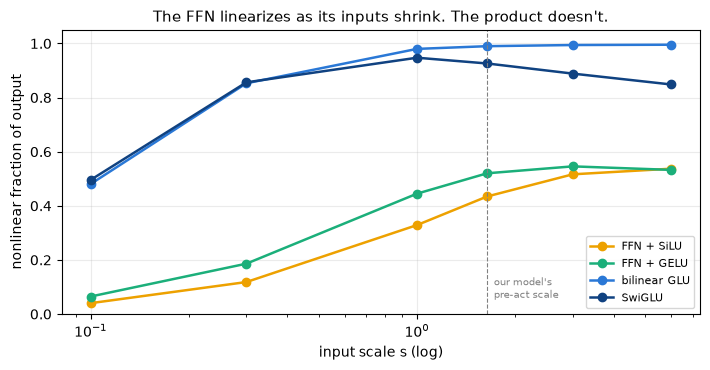

In [8]:
plt.figure(figsize=(7.2, 3.8))
COLORS = {"FFN + SiLU": "#eda100", "FFN + GELU": "#1baf7a",
          "bilinear GLU": "#2a78d6", "SwiGLU": "#104281"}
for nm, _ in probes:
    plt.plot(SCALES, frac[nm], "o-", lw=1.8, color=COLORS[nm], label=nm)
plt.axvline(1.64, ls="--", c="gray", lw=0.8)
plt.text(1.72, 0.06, "our model's\npre-act scale", fontsize=7.5, color="gray")
plt.xscale("log")
plt.ylim(0, 1.05)
plt.xlabel("input scale s (log)")
plt.ylabel("nonlinear fraction of output")
plt.title("The FFN linearizes as its inputs shrink. The product doesn't.", fontsize=11)
plt.legend(fontsize=8, loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## What the product buys: multiplication is a thing networks are bad at

The algebra says a GLU computes `x_i·x_j` cross-terms. Here's why that's worth a matrix.

Ask both layers to learn the simplest multiplicative function there is: `f(a, b) = a·b`.
A bilinear layer should nail it *exactly* with **one** hidden unit — set `up` to read
`a`, `gate` to read `b`, and the product is the answer. An MLP has to approximate a
curved surface by summing bent lines, which it can only do over the range it was shown.

Train on `a, b ∈ [-2, 2]`, then test **inside** that box and **far outside** it:

In [9]:
torch.manual_seed(0)


def make_ab(n, lo, hi):
    ab = torch.rand(n, 2) * (hi - lo) + lo
    return ab, (ab[:, 0] * ab[:, 1]).unsqueeze(1)


Xtr, Ytr = make_ab(8192, -2, 2)
Xte, Yte = make_ab(4096, -2, 2)          # in-distribution
Xfar, Yfar = make_ab(4096, -6, 6)        # 3x outside the training box


def fit(model, iters=4000, lr=3e-3):
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    for _ in range(iters):
        idx = torch.randint(len(Xtr), (256,))
        loss = F.mse_loss(model(Xtr[idx]), Ytr[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
    with torch.no_grad():
        return (F.mse_loss(model(Xte), Yte).item(),
                F.mse_loss(model(Xfar), Yfar).item())


rows, fitted = [], {}
for h in (4, 16, 64):
    torch.manual_seed(0)
    m = nn.Sequential(nn.Linear(2, h), nn.GELU(), nn.Linear(h, 1))
    rows.append((f"MLP + GELU, h={h}", sum(p.numel() for p in m.parameters()), *fit(m)))
    fitted[f"mlp{h}"] = m
for h in (1, 4):
    torch.manual_seed(0)
    m = Bilinear(2, h, 1, bias=True)
    rows.append((f"bilinear GLU, h={h}",
                 sum(p.numel() for p in m.parameters()), *fit(m)))
    fitted[f"bil{h}"] = m

print(f"{'model':<20} | {'params':>6} | {'MSE in [-2,2]':>14} | {'MSE in [-6,6]':>14}")
print("-" * 62)
for name, p, mse, far in rows:
    print(f"{name:<20} | {p:>6} | {mse:>14.2e} | {far:>14.2e}")

model                | params |  MSE in [-2,2] |  MSE in [-6,6]
--------------------------------------------------------------
MLP + GELU, h=4      |     17 |       2.65e-02 |       5.50e+01
MLP + GELU, h=16     |     65 |       4.11e-04 |       3.13e+01
MLP + GELU, h=64     |    257 |       9.56e-05 |       2.25e+01
bilinear GLU, h=1    |      8 |       2.51e-08 |       1.99e-06
bilinear GLU, h=4    |     29 |       3.54e-09 |       2.89e-07


**One hidden unit and 8 parameters beat 64 hidden units and 257.** In-distribution the
big MLP gets close — that's the universal-approximation theorem doing its job, and with
enough units it would get closer still. Step outside the training box and its error is
~10⁷ times the bilinear's, because it never learned multiplication; it learned a
patchwork of bends that happened to look like `a·b` where it was shown data.

The bilinear layer didn't approximate `a·b`. It **is** `a·b`, so "outside the training
range" doesn't mean anything to it. Read the `h=1` weights and you can watch it happen:

In [10]:
m = fitted["bil1"]
u, g, p = (m.up.weight.data.flatten(), m.gate.weight.data.flatten(),
           m.proj.weight.data.flatten())
print(f"up   reads: {u[0]:+.3f}·a {u[1]:+.3f}·b")
print(f"gate reads: {g[0]:+.3f}·a {g[1]:+.3f}·b")
print(f"proj scale: {p[0]:+.3f}")
prod = u.abs().max() * g.abs().max() * p[0].abs()
print("\n-> one branch picked out `a`, the other picked out `b`, and the product")
print(f"   of the three scale factors is {prod:.4f} ≈ 1. It found f(a,b) = a·b.")

up   reads: -0.000·a +1.145·b
gate reads: -1.264·a +0.000·b
proj scale: -0.691

-> one branch picked out `a`, the other picked out `b`, and the product
   of the three scale factors is 0.9999 ≈ 1. It found f(a,b) = a·b.


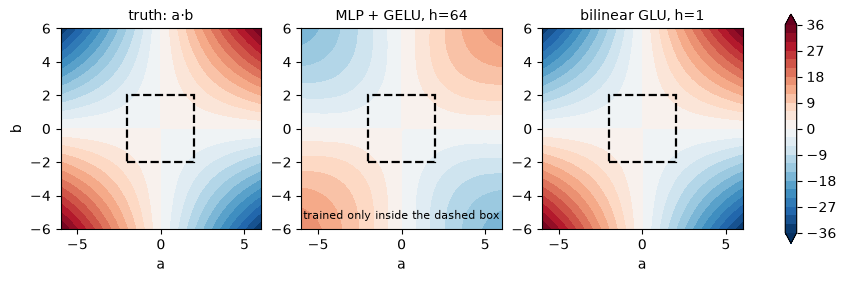

In [11]:
gr = torch.linspace(-6, 6, 121)
A, B = torch.meshgrid(gr, gr, indexing="ij")
grid = torch.stack([A.flatten(), B.flatten()], dim=1)
panels = [("truth: a·b", (A * B)),
          ("MLP + GELU, h=64", None), ("bilinear GLU, h=1", None)]
with torch.no_grad():
    panels[1] = ("MLP + GELU, h=64", fitted["mlp64"](grid).view(121, 121))
    panels[2] = ("bilinear GLU, h=1", fitted["bil1"](grid).view(121, 121))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, (title, Z) in zip(axes, panels):
    im = ax.contourf(A, B, Z, levels=torch.linspace(-36, 36, 25), cmap="RdBu_r",
                     extend="both")
    ax.add_patch(plt.Rectangle((-2, -2), 4, 4, fill=False, ec="k", lw=1.6, ls="--"))
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("a")
    ax.set_aspect("equal")
axes[0].set_ylabel("b")
axes[1].text(0, -5.4, "trained only inside the dashed box", fontsize=8, ha="center")
fig.colorbar(im, ax=axes, shrink=0.85)
plt.show()

The middle panel is the lesson. Inside the dashed box the MLP reproduces `a·b`
convincingly; outside it, the saddle just stops — the bends it learned run out and the
surface flattens into nonsense. The right panel is the same everywhere, because it isn't
imitating a product, it's performing one.

That's the case for the gate in one picture. Whether it's worth a third matrix on real
text is a different question, and it's the next one.

## The parameter tax, and where `8C/3` comes from

The GLU has three matrices where the FFN has two, so at the same hidden width it's
**1.5x the parameters**. Comparing it to `06`'s FFN like that would be a cheat: we'd be
measuring the extra capacity, not the gate. So shrink the hidden width until the counts
match. Ignoring biases, with embedding width `C` and hidden width `H`:

```-
FFN params = C·(4C)  +  (4C)·C           = 8C²          <- H fixed at 4C
GLU params = C·H  +  C·H  +  H·C         = 3CH

3CH = 8C²   ->   H = 8C/3 ≈ 2.67C
```

**That's the whole origin of the famous `8C/3`.** It isn't a tuned constant or a magic
ratio — it's just the width at which three matrices cost what two matrices cost, so the
comparison is fair. Every Llama-family config carries it around.

In [12]:
for C_ in (EMBD, 4096):
    print(f"C = {C_:>5}:  FFN(4C) = {8 * C_ * C_:>11,} params  ->  "
          f"GLU needs H = 8C/3 = {8 * C_ / 3:.1f}")
H_GLU = 344                      # 8*128/3 = 341.33, rounded up to a multiple of 8
print(f"\nours   : H = {H_GLU} (341.33 rounded to a multiple of 8) -> "
      f"{3 * EMBD * H_GLU / (8 * EMBD * EMBD):.3f}x the FFN's params")
print(f"Llama-7B: C = 4096, 8C/3 = 10922.7 -> ships H = 11008 (multiple of 256) -> "
      f"{3 * 4096 * 11008 / (8 * 4096 ** 2):.3f}x")
print("\nBoth round UP to a hardware-friendly width and overshoot by the same 0.8%.")
print("So 'param-matched' means matched to <1%, and we'll note it when it matters.")

C =   128:  FFN(4C) =     131,072 params  ->  GLU needs H = 8C/3 = 341.3
C =  4096:  FFN(4C) = 134,217,728 params  ->  GLU needs H = 8C/3 = 10922.7

ours   : H = 344 (341.33 rounded to a multiple of 8) -> 1.008x the FFN's params
Llama-7B: C = 4096, 8C/3 = 10922.7 -> ships H = 11008 (multiple of 256) -> 1.008x

Both round UP to a hardware-friendly width and overshoot by the same 0.8%.
So 'param-matched' means matched to <1%, and we'll note it when it matters.


## The model, feed-forward-swappable

`06`'s GPT with the FFN passed in as a factory — the only thing that varies below.
Everything else (`07`'s recipe, the norm, the attention) is untouched from `10`.

In [13]:
class CausalSelfAttention(nn.Module):
    """All heads at once: qkv projection, reshape to (B, nh, T, hs), masked softmax."""

    def __init__(self, n_embd, n_head, block_size=BLOCK):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head, self.n_embd = n_head, n_embd
        self.head_size = n_embd // n_head
        self.qkv = nn.Linear(n_embd, 3 * n_embd, bias=False)
        self.proj = nn.Linear(n_embd, n_embd)
        self.proj.RESIDUAL_PROJ = True
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        nh, hs = self.n_head, self.head_size
        q, k, v = self.qkv(x).split(self.n_embd, dim=-1)
        q = q.view(B, T, nh, hs).transpose(1, 2)
        k = k.view(B, T, nh, hs).transpose(1, 2)
        v = v.view(B, T, nh, hs).transpose(1, 2)
        scores = q @ k.transpose(-2, -1) * hs ** -0.5
        scores = scores.masked_fill(self.tril[:T, :T] == 0, float("-inf"))
        out = F.softmax(scores, dim=-1) @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(out)


class Block(nn.Module):
    """06's Block, with the feed-forward injected as a factory."""

    def __init__(self, n_embd, n_head, ffn_fn, block_size=BLOCK):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, block_size)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ffwd = ffn_fn(n_embd)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


class GPT(nn.Module):
    """06's GPT. `ffn_fn(n_embd)` builds a fresh feed-forward per block."""

    def __init__(self, vocab_size, ffn_fn, n_embd=EMBD, n_head=4, n_layer=4,
                 block_size=BLOCK):
        super().__init__()
        self.block_size, self.n_layer = block_size, n_layer
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.blocks = nn.ModuleList(
            [Block(n_embd, n_head, ffn_fn, block_size) for _ in range(n_layer)]
        )
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))
        for block in self.blocks:
            x = block(x)
        logits = self.lm_head(self.ln_f(x))
        loss = None
        if targets is not None:
            B, T, V = logits.shape
            loss = F.cross_entropy(logits.view(B * T, V), targets.view(B * T))
        return logits, loss

In [14]:
def apply_gpt2_init(model):
    """07's Knob 1: N(0, 0.02), residual projections scaled by 1/sqrt(2*n_layer)."""
    for mod in model.modules():
        if isinstance(mod, nn.Linear):
            std = 0.02 * ((2 * model.n_layer) ** -0.5
                          if getattr(mod, "RESIDUAL_PROJ", False) else 1.0)
            nn.init.normal_(mod.weight, std=std)
            if mod.bias is not None:
                nn.init.zeros_(mod.bias)
        elif isinstance(mod, nn.Embedding):
            nn.init.normal_(mod.weight, std=0.02)
    return model


def get_lr(step, *, warmup, max_steps, max_lr, min_lr):
    """07's Knob 3: linear warmup to max_lr, then half-cosine decay to min_lr."""
    if step < warmup:
        return max_lr * (step + 1) / warmup
    ratio = min((step - warmup) / (max_steps - warmup), 1.0)
    return min_lr + 0.5 * (1 + math.cos(math.pi * ratio)) * (max_lr - min_lr)


@torch.no_grad()
def full_val_loss(m, bs=256):
    """The same deterministic whole-val-split metric `03`–`10` reported."""
    m.eval()
    nwin = (len(val_data) - 1) // BLOCK
    x = val_data[:nwin * BLOCK].view(nwin, BLOCK)
    y = val_data[1:nwin * BLOCK + 1].view(nwin, BLOCK)
    total = count = 0
    for i in range(0, nwin, bs):
        xb, yb = x[i:i + bs].to(DEV), y[i:i + bs].to(DEV)
        total += m(xb, yb)[1].item() * yb.numel()
        count += yb.numel()
    m.train()
    return total / count


def train(m, max_iters=3000, max_lr=3e-3, min_lr=3e-4, warmup=100):
    """07's recipe, unchanged: GPT-2 init, AdamW 2-group decay, warmup+cosine, clip."""
    apply_gpt2_init(m)
    params = [p for p in m.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(
        [{"params": [p for p in params if p.dim() >= 2], "weight_decay": 0.1},
         {"params": [p for p in params if p.dim() < 2], "weight_decay": 0.0}],
        lr=max_lr, betas=(0.9, 0.95),
    )
    for it in range(max_iters + 1):
        for g in opt.param_groups:
            g["lr"] = get_lr(it, warmup=warmup, max_steps=max_iters,
                             max_lr=max_lr, min_lr=min_lr)
        xb, yb = get_batch("train")
        _, loss = m(xb, yb)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()
    return m


TRAINED = {}          # keep: the seed-1337 model per config, so later sections reuse it
CHECK_SEEDS = (1337, 7)   # 2 seeds for side-checks; 3 for anything we draw a claim from


def run_seeds(ffn_fn, seeds=(1337, 7, 42), keep=None):
    """Train one model per seed, return the list of final val losses.

    `keep` caches the first seed's trained model under that name in TRAINED, so a
    later section can analyse it instead of paying to train the same thing twice.
    """
    out = []
    for s in seeds:
        torch.manual_seed(s)
        m = train(GPT(vocab_size, ffn_fn).to(DEV))
        if keep is not None and s == seeds[0]:
            TRAINED[keep] = m
        out.append(full_val_loss(m))
    return out

## The experiment is a 2x2

There are **two** ways to put a nonlinearity in a feed-forward, and they're independent:
a fixed **activation** on the hidden layer, and a **gate** (the product). `10` only ever
varied the first. So don't run an A/B — run the grid, param-matched, 3 seeds a cell:

```-
                    | no activation      | with activation
  ------------------+--------------------+-------------------------
  no gate  (FFN)    | 10's collapse      | 06's FFN (GELU)
  gate     (GLU)    | bilinear           | SwiGLU  (SiLU gate)
```

The diagonal is what makes it worth running. If the gate and the activation are two
routes to the same thing, the off-diagonal cells should land together and the corner
should buy nothing. If they're complementary, the corner wins.

In [15]:
CELLS = {
    ("no gate", "no act"): lambda c: FeedForward(c, 4 * c, nn.Identity()),
    ("no gate", "act"): lambda c: FeedForward(c, 4 * c, nn.GELU()),
    ("gate", "no act"): lambda c: GLUFeedForward(c, H_GLU, nn.Identity()),
    ("gate", "act"): lambda c: GLUFeedForward(c, H_GLU, nn.SiLU()),
}
grid = {}
print(f"{'cell':<28} | {'ffn params':>10} | {'seed runs':<24} | {'mean':>7}")
print("-" * 78)
for key, fn in CELLS.items():
    # the SwiGLU cell's first model is reused (not retrained) by the sections below
    grid[key] = run_seeds(fn, keep="swiglu" if key == ("gate", "act") else None)
    pf = sum(p.numel() for p in fn(EMBD).parameters())
    label = f"{key[0]:<8} x {key[1]}"
    print(f"{label:<28} | {pf:>10,} | "
          f"{'  '.join(f'{v:.4f}' for v in grid[key]):<24} | "
          f"{sum(grid[key]) / 3:>7.4f}")

cell                         | ffn params | seed runs                |    mean
------------------------------------------------------------------------------


no gate  x no act            |    131,712 | 1.8485  1.8230  1.8431   |  1.8382


no gate  x act               |    131,712 | 1.5787  1.5711  1.5692   |  1.5730


gate     x no act            |    132,912 | 1.5710  1.5660  1.5676   |  1.5682


gate     x act               |    132,912 | 1.5636  1.5285  1.5562   |  1.5495


In [16]:
mean = lambda k: sum(grid[k]) / len(grid[k])
spread = max(max(v) - min(v) for v in grid.values())
print("val loss, param-matched, 3 seeds each\n")
print(f"{'':<16} | {'no activation':>14} | {'with activation':>16}")
print("-" * 52)
print(f"{'no gate (FFN)':<16} | {mean(('no gate', 'no act')):>14.4f} | "
      f"{mean(('no gate', 'act')):>16.4f}")
print(f"{'gate (GLU)':<16} | {mean(('gate', 'no act')):>14.4f} | "
      f"{mean(('gate', 'act')):>16.4f}")
print(f"\nworst within-cell seed spread: {spread:.4f}")

# With 3 seeds, "mean gap vs mean spread" is a weak test. The strong one: do the two
# cells' seed RANGES overlap at all? Non-overlapping = every seed of one beat every
# seed of the other, which no amount of seed luck explains.
GATE, ACT = ("gate", "no act"), ("no gate", "act")
BOTH = ("gate", "act")


def overlaps(a, b):
    return not (max(grid[a]) < min(grid[b]) or max(grid[b]) < min(grid[a]))


print(f"gate alone vs activation alone: {abs(mean(GATE) - mean(ACT)):.4f} apart, "
      f"ranges overlap: {overlaps(GATE, ACT)}")
print(f"  -> [{min(grid[GATE]):.4f}, {max(grid[GATE]):.4f}] vs "
      f"[{min(grid[ACT]):.4f}, {max(grid[ACT]):.4f}]  == a tie")
best_single = min(mean(GATE), mean(ACT))
print(f"\nboth vs the best of either   : {best_single - mean(BOTH):.4f} better, "
      f"ranges overlap: {overlaps(BOTH, GATE) or overlaps(BOTH, ACT)}")
print(f"  -> SwiGLU [{min(grid[BOTH]):.4f}, {max(grid[BOTH]):.4f}] sits entirely below "
      f"both  == real")

val loss, param-matched, 3 seeds each

                 |  no activation |  with activation
----------------------------------------------------
no gate (FFN)    |         1.8382 |           1.5730
gate (GLU)       |         1.5682 |           1.5495

worst within-cell seed spread: 0.0351
gate alone vs activation alone: 0.0048 apart, ranges overlap: True
  -> [1.5660, 1.5710] vs [1.5692, 1.5787]  == a tie

both vs the best of either   : 0.0188 better, ranges overlap: False
  -> SwiGLU [1.5285, 1.5636] sits entirely below both  == real


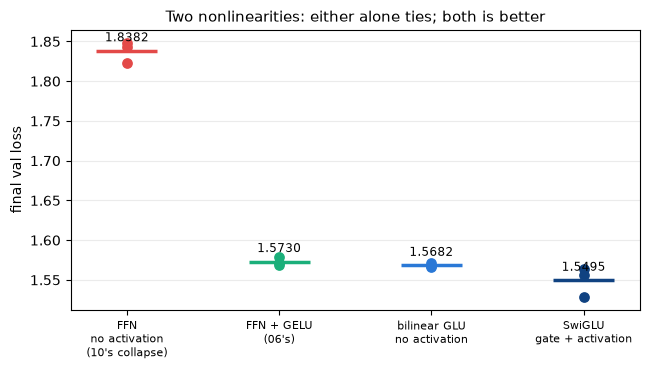

In [17]:
plt.figure(figsize=(6.6, 3.8))
ORDER = [("no gate", "no act"), ("no gate", "act"), ("gate", "no act"), ("gate", "act")]
NAMES = ["FFN\nno activation\n(10's collapse)", "FFN + GELU\n(06's)",
         "bilinear GLU\nno activation", "SwiGLU\ngate + activation"]
CLR = ["#e34948", "#1baf7a", "#2a78d6", "#104281"]
for i, (k, c) in enumerate(zip(ORDER, CLR)):
    plt.scatter([i] * len(grid[k]), grid[k], s=45, color=c, zorder=3)
    plt.hlines(mean(k), i - 0.2, i + 0.2, lw=2.5, color=c)
    plt.text(i, mean(k) + 0.012, f"{mean(k):.4f}", ha="center", fontsize=8.5)
plt.xticks(range(4), NAMES, fontsize=8)
plt.ylabel("final val loss")
plt.title("Two nonlinearities: either alone ties; both is better", fontsize=11)
plt.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

### Reading the grid

**The off-diagonal is a dead heat.** A GLU with *no activation function at all* and an
FFN with *no gate* land within a hair of each other — comfortably inside the seed spread
— while the cell with neither is a catastrophe. So the two mechanisms are, to this
model's eye, **interchangeable ways to buy the same first unit of nonlinearity**. That's
already a surprise worth sitting with: `10` spent a whole notebook establishing that the
activation is indispensable, and here's a layer that throws it away and pays nothing,
because it bought its nonlinearity somewhere else.

**And the corner wins.** Stack both and you get a further improvement — smaller, but
real: SwiGLU's three seeds sit *entirely below* both off-diagonal cells' three, so no
seed luck explains it. So they aren't redundant either — the gate and the activation
contribute *different* nonlinearity, and the model uses both. But notice the shape of
it: the first mechanism is worth ~0.27 of loss and the second only ~0.02. **Massively
diminishing returns.** The first nonlinearity rescues the layer from being a matrix; the
second is a refinement.

That asymmetry is the frame for everything below. If the activation is a refinement
rather than the main event, then all of `10`'s careful ranking of activations should
matter much *less* inside a GLU than it did inside an FFN. Let's go check that directly.

## The GLU zoo, and Shazeer's shrug

`10`'s zoo had a clear pecking order, well outside seed noise: GELU beat SiLU, and the
saturating activations were disasters. Swap each of those activations into the **gate**
of a param-matched GLU and the same question gets asked in a world where the product is
already doing the heavy lifting.

Shazeer tried all of these in 2020, found they all worked, and declined to explain it.
The 2x2 above gives us a prediction he didn't have: since the activation is only worth
~0.02 here, the *spread across activations* should collapse toward noise.

In [18]:
ZOO = [
    ("bilinear (none)", nn.Identity),
    ("ReGLU (ReLU)", nn.ReLU),
    ("GEGLU (GELU)", nn.GELU),
    ("SwiGLU (SiLU)", nn.SiLU),
]
zoo_res = {"bilinear (none)": grid[("gate", "no act")],
           "SwiGLU (SiLU)": grid[("gate", "act")]}
for name, act in ZOO:
    if name not in zoo_res:
        zoo_res[name] = run_seeds(lambda c, a=act: GLUFeedForward(c, H_GLU, a()))

print(f"{'GLU variant':<18} | {'seed runs':<24} | {'mean':>7}")
print("-" * 56)
for name, _ in ZOO:
    v = zoo_res[name]
    print(f"{name:<18} | {'  '.join(f'{x:.4f}' for x in v):<24} | "
          f"{sum(v) / len(v):>7.4f}")

gated = [sum(zoo_res[n]) / 3 for n, _ in ZOO if n != "bilinear (none)"]
print(f"\nspread across the three ACTIVATED variants : {max(gated) - min(gated):.4f}")
print(f"worst within-variant seed spread           : "
      f"{max(max(v) - min(v) for v in zoo_res.values()):.4f}")
print("\n10, for contrast — same activations, no gate:")
print("  GELU 1.5724 vs SiLU ~1.616 — a 0.04 gap that held on every seed.")

GLU variant        | seed runs                |    mean
--------------------------------------------------------
bilinear (none)    | 1.5710  1.5660  1.5676   |  1.5682
ReGLU (ReLU)       | 1.5599  1.5629  1.5597   |  1.5608
GEGLU (GELU)       | 1.5568  1.5469  1.5548   |  1.5528
SwiGLU (SiLU)      | 1.5636  1.5285  1.5562   |  1.5495

spread across the three ACTIVATED variants : 0.0114
worst within-variant seed spread           : 0.0351

10, for contrast — same activations, no gate:
  GELU 1.5724 vs SiLU ~1.616 — a 0.04 gap that held on every seed.


**The pecking order is gone.** ReGLU, GEGLU and SwiGLU are separated by less than the
noise between seeds of a single one of them. In `10` this same choice — the *same five
curves* — produced a clear, reproducible ranking, and SiLU's deficit against GELU was
one of that notebook's central puzzles. Put those curves in a gate and the question
stops having an answer.

This is what `10`'s mechanism predicts, and it's satisfying to watch it land. `10`
diagnosed the SiLU-vs-GELU gap as **curvature**: `x·sigmoid(beta·x) ≈ 0.5x +
(beta/4)x²`, so a softer gate is literally a straighter line, and the FFN's whole
nonlinearity budget came from that one term. Being 40% less curved than GELU cost SiLU
real loss.

Inside a GLU that budget isn't scarce any more. The product supplies a nonlinearity that
doesn't depend on the activation's curvature at all — the bilinear row proves the layer
works with the curvature set to *zero*. So the activation's remaining job is a
second-order refinement, and second-order refinements don't reproduce first-order
rankings.

Which is a real, if partial, answer to the shrug. Shazeer couldn't say why the GLU
variants all work; the 2x2 says **they all work because the variant isn't what's
working**. What that doesn't explain is the leftover ~0.02 — why the activated gate
beats the bare product at all. That part we're leaving where he left it.

## Is it the gate, or is it the parameters?

One nagging alternative: the GLU cells are +0.9% parameters (the rounding to 344), and
maybe the whole win is capacity. Two checks settle it.

**Give the GLU *more* params, not fewer.** Run SwiGLU at the FFN's full `4C = 512`
hidden width — a 32% bigger feed-forward, no longer matched to anything. If capacity is
what's buying the win, this should extend it.

**Take the biases away.** Llama's FFN has none, and the homogeneity result above says
that's not just parameter thrift — the biases are what let a GLU linearize at small
scale. It costs 816 parameters to check.

In [19]:
# These are side-checks, not the headline, so 2 seeds each — and the matched SwiGLU
# reuses its FIRST TWO seeds from the grid, so every row below is the same 2 seeds.
extra = {
    "SwiGLU H=344 (matched)": grid[("gate", "act")][:len(CHECK_SEEDS)],
    "SwiGLU H=512 (+32% params)": run_seeds(
        lambda c: GLUFeedForward(c, 4 * c, nn.SiLU()), seeds=CHECK_SEEDS),
    "SwiGLU H=344, no biases": run_seeds(
        lambda c: GLUFeedForward(c, H_GLU, nn.SiLU(), bias=False), seeds=CHECK_SEEDS),
}
sizes = {
    "SwiGLU H=344 (matched)": GLUFeedForward(EMBD, H_GLU, nn.SiLU()),
    "SwiGLU H=512 (+32% params)": GLUFeedForward(EMBD, 4 * EMBD, nn.SiLU()),
    "SwiGLU H=344, no biases": GLUFeedForward(EMBD, H_GLU, nn.SiLU(), bias=False),
}
avg = lambda v: sum(v) / len(v)
print(f"{'variant':<28} | {'ffn params':>10} | {'mean val':>9}  (2 seeds)")
print("-" * 62)
print(f"{'FFN + GELU (06 baseline)':<28} | "
      f"{sum(p.numel() for p in FeedForward(EMBD).parameters()):>10,} | "
      f"{avg(grid[('no gate', 'act')][:len(CHECK_SEEDS)]):>9.4f}")
for name, v in extra.items():
    pf = sum(p.numel() for p in sizes[name].parameters())
    print(f"{name:<28} | {pf:>10,} | {avg(v):>9.4f}")

matched = avg(extra["SwiGLU H=344 (matched)"])
big_gain = matched - avg(extra["SwiGLU H=512 (+32% params)"])
bias_gain = matched - avg(extra["SwiGLU H=344, no biases"])
print(f"\n(positive = BETTER than matched SwiGLU; seed spread ~{spread:.4f})")
print(f"+32% params on top of SwiGLU : {big_gain:+.4f} val loss")
print(f"deleting every bias          : {bias_gain:+.4f} val loss")
print("\n-> +32% params changes nothing: the gate does the work, not the capacity,")
print("   so shrinking the hidden width to 8C/3 to pay for it is nearly free.")
print("-> dropping the biases costs a little, but far inside the seed spread — i.e.")
print("   nothing we can resolve with 2 seeds. Llama drops them; we can't fault it.")

variant                      | ffn params |  mean val  (2 seeds)
--------------------------------------------------------------
FFN + GELU (06 baseline)     |    131,712 |    1.5749
SwiGLU H=344 (matched)       |    132,912 |    1.5461
SwiGLU H=512 (+32% params)   |    197,760 |    1.5467
SwiGLU H=344, no biases      |    132,096 |    1.5550

(positive = BETTER than matched SwiGLU; seed spread ~0.0351)
+32% params on top of SwiGLU : -0.0006 val loss
deleting every bias          : -0.0090 val loss

-> +32% params changes nothing: the gate does the work, not the capacity,
   so shrinking the hidden width to 8C/3 to pay for it is nearly free.
-> dropping the biases costs a little, but far inside the seed spread — i.e.
   nothing we can resolve with 2 seeds. Llama drops them; we can't fault it.


**Capacity is not the story.** A 32% bigger feed-forward buys *nothing at all* — it
comes out a hair worse, which at this seed count means "identical". Meanwhile the gate
at *matched* size bought ~0.02. That's the cleanest form of the claim: SwiGLU isn't
winning because three matrices are more than two — it's winning at the width where three
matrices cost exactly what two did.

It also retro-justifies `8C/3`. If the extra width were valuable you'd resent paying for
the gate out of the hidden dimension; measured here, the width you give up is worth
nothing and the gate you buy with it is worth ~0.02. That trade is why every
Llama-family model makes it.

The biases are the weaker result, and it's worth saying so rather than rounding it in
our favour. Dropping them costs ~0.01 here — the right sign to notice, but a third of
the seed spread, so with 2 seeds we genuinely cannot tell it from zero. What we can say
is that the homogeneity argument gives Llama a *reason* beyond thrift: the bias terms
are the only thing handing a bilinear layer a linear regime to decay into. Our
measurement doesn't confirm that pays off at this scale; it just fails to contradict it.

## A hypothesis about *why*, and its death

Here's the explanation I expected to write, built directly on `10`'s ending.

`10` found the FFN's real problem was **effective sharpness**, `beta*s` — the gate's
sharpness times the pre-activation scale. Plain SiLU's ran `[2.1, 2.1, 1.0, 0.3]` across
blocks: fine at first, then **collapsing into the near-linear regime with depth**. And
`10` explained why the model couldn't fix it itself: `s` is set by `fc`'s weights, so
sharpening the gate means scaling `fc` up *and* `proj` down together — a two-matrix
coordination that weight decay fights and AdamW never finds.

**A GLU seems to hand the model exactly the knob it was missing.** The gate now has its
*own* matrix `V`, separate from the value matrix `W`. Scaling `V` up sharpens the gate
without touching the value branch. So the prediction: SwiGLU's gate branch should run at
a **sharper** `s` than `10`'s FFN managed — up in the 3–5 band `10` measured as optimal.

Both models, same measurement, same hook:

In [20]:
swiglu_m = TRAINED["swiglu"]        # the grid's seed-1337 SwiGLU, not a fresh run
swiglu_m.eval()
torch.manual_seed(1337)             # 10's FFN is the one model this section must train
silu_ffn = train(GPT(vocab_size, lambda c: FeedForward(c, 4 * c, nn.SiLU())).to(DEV))
silu_ffn.eval()
print(f"SwiGLU val {full_val_loss(swiglu_m):.4f}   |   "
      f"10's SiLU-FFN val {full_val_loss(silu_ffn):.4f}")

SwiGLU val 1.5636   |   10's SiLU-FFN val 1.6301


In [21]:
@torch.no_grad()
def preact_std(m, pick, batches=8):
    """Per-block std of the tensor leaving `pick(ffwd)` — the layer feeding the act.
    Hooks fire in block order, so stats[i::n_blocks] are block i's readings."""
    stats, handles = [], []
    for b in m.blocks:
        handles.append(pick(b.ffwd).register_forward_hook(
            lambda mod, i, o: stats.append(o.std().item())))
    for _ in range(batches):
        m(get_batch("val")[0])
    for h in handles:
        h.remove()
    nb = len(m.blocks)
    return [sum(stats[i::nb]) / len(stats[i::nb]) for i in range(nb)]


fmt = lambda v: "[" + "  ".join(f"{x:.2f}" for x in v) + "]"
ffn_s = preact_std(silu_ffn, lambda f: f.fc)
gate_s = preact_std(swiglu_m, lambda f: f.gate)
val_s = preact_std(swiglu_m, lambda f: f.up)
print("pre-activation scale s per block (SiLU has beta=1, so sharpness = s)\n")
print(f"  10's FFN, SiLU     : {fmt(ffn_s)}   <- collapses with depth")
print(f"  SwiGLU gate branch : {fmt(gate_s)}   <- flat")
print(f"  SwiGLU value branch: {fmt(val_s)}")
print(f"\n10's measured optimum was beta*s ≈ 3-5. The SwiGLU gate sits at "
      f"~{sum(gate_s) / len(gate_s):.1f}.")

pre-activation scale s per block (SiLU has beta=1, so sharpness = s)

  10's FFN, SiLU     : [2.20  2.02  1.33  0.48]   <- collapses with depth
  SwiGLU gate branch : [1.47  1.39  1.35  1.41]   <- flat
  SwiGLU value branch: [1.42  1.36  1.27  1.27]

10's measured optimum was beta*s ≈ 3-5. The SwiGLU gate sits at ~1.4.


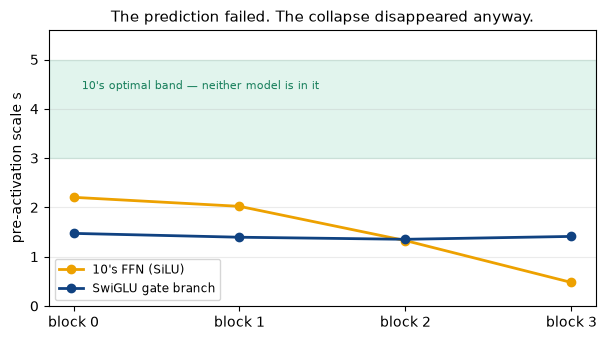

In [22]:
plt.figure(figsize=(6.2, 3.5))
plt.plot(range(4), ffn_s, "o-", lw=2, color="#eda100", label="10's FFN (SiLU)")
plt.plot(range(4), gate_s, "o-", lw=2, color="#104281", label="SwiGLU gate branch")
plt.axhspan(3, 5, color="#1baf7a", alpha=0.13)
plt.text(0.05, 4.4, "10's optimal band — neither model is in it", fontsize=8,
         color="#177f5b")
plt.xticks(range(4), [f"block {i}" for i in range(4)])
plt.ylabel("pre-activation scale s")
plt.ylim(0, 5.6)
plt.title("The prediction failed. The collapse disappeared anyway.", fontsize=11)
plt.legend(fontsize=8.5)
plt.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

**The hypothesis is dead, and the way it died is the finding.**

The SwiGLU gate does **not** run sharper. It sits at `s ≈ 1.4` — *softer* than `10`'s
FFN starts at, and squarely in the near-linear end of `10`'s sweep, the regime that
notebook spent pages establishing is bad. It never goes near the 3–5 band. And it beats
the SiLU-FFN by a wide margin anyway.

So the free knob is real and the model **declines to turn it**, which kills the tidy
story. But look at the *shape* of the two curves, because that's what actually changed:

- `10`'s FFN: `2.20 → 0.48`. Its effective sharpness **falls ~4.5x with depth**. The
  deepest block is running a nearly-linear FFN, which `10` identified as SiLU's real
  defect ("deep blocks slide into the linear regime and have no way to climb out").
- SwiGLU's gate: essentially **flat across all four blocks**. No collapse.

And the flatness isn't the model working to prevent a collapse — it's that **there's
nothing to collapse into.** That's the homogeneity result from the top of the notebook,
arriving with a job to do. `10`'s FFN had a linear regime waiting at small `s`, and
depth walked into it. A product is degree-2 homogeneous: the nonlinear fraction is the
same at `s = 0.03` and `s = 3`, so drifting to a small scale costs it *nothing*. The
layer is scale-free, so `s` stops being a thing that can go wrong.

That reframes the win. SwiGLU isn't better because its gate is sharper — measured, it
isn't. It's better because **its nonlinearity doesn't depend on the gate's sharpness at
all**, so the failure mode `10` spent its second half diagnosing simply cannot occur.
The knob I expected the model to turn is one it no longer needs.

### One more check: is the gate actually looking somewhere new?

The premise of the whole notebook is that the gate gets its own view of `x`. But nothing
*forces* it to use one — if training drove `V → W`, the gate would collapse back into
`Swish(W·x)` and we'd be back in `10`. Compare each hidden unit's two rows:

In [23]:
print("cosine similarity between each hidden unit's value row and its gate row")
print("(1.0 = the gate is just looking at the value again = plain Swish)\n")
for i, b in enumerate(swiglu_m.blocks):
    cos = F.cosine_similarity(b.ffwd.up.weight, b.ffwd.gate.weight, dim=-1)
    print(f"  block{i}: mean |cos| = {cos.abs().mean():.3f}   "
          f"max {cos.abs().max():.3f}")
r1, r2 = torch.randn(H_GLU, EMBD), torch.randn(H_GLU, EMBD)
rand_cos = F.cosine_similarity(r1, r2, dim=-1).abs().mean()
print(f"\n  random reference: {rand_cos:.3f}  <- two unrelated projections, width 128")
print("\nThe gate stays far from its value row — nowhere near collapsing back to")
print("Swish — but it is ~2.5x more aligned than chance: a related view, not a")
print("random one.")

cosine similarity between each hidden unit's value row and its gate row
(1.0 = the gate is just looking at the value again = plain Swish)

  block0: mean |cos| = 0.184   max 0.832
  block1: mean |cos| = 0.167   max 0.742
  block2: mean |cos| = 0.187   max 0.695
  block3: mean |cos| = 0.207   max 0.713

  random reference: 0.071  <- two unrelated projections, width 128

The gate stays far from its value row — nowhere near collapsing back to
Swish — but it is ~2.5x more aligned than chance: a related view, not a
random one.


## What it costs

`09` taught the lesson this section exists to reapply: **counting arithmetic predicts
nothing; measure.** SwiGLU is param-matched and FLOP-matched to the FFN by construction,
so a naive count says the two should cost the same. They don't quite. Three matmuls at
an awkward inner width beat two at a clean one — on kernel selection, on launch
overhead, and on the extra activation tensor the product needs. Measured at a realistic
width:

In [24]:
W_BENCH, T_BENCH = 1024, 4096
H_BENCH = 8 * W_BENCH // 3 // 8 * 8               # 8C/3, rounded to a multiple of 8
xb_bench = torch.randn(T_BENCH, W_BENCH, device=DEV)
ffn_b = FeedForward(W_BENCH, 4 * W_BENCH, nn.GELU()).to(DEV)
glu_b = GLUFeedForward(W_BENCH, H_BENCH, nn.SiLU()).to(DEV)


def bench(mod, x, iters=30):
    """Median ms per fwd+bwd, after warmup. CUDA-synced: time the GPU, not the queue."""
    x = x.clone().requires_grad_(True)
    for _ in range(8):
        mod(x).sum().backward()
    if DEV == "cuda":
        torch.cuda.synchronize()
    ts = []
    for _ in range(iters):
        t0 = time.perf_counter()
        mod(x).sum().backward()
        if DEV == "cuda":
            torch.cuda.synchronize()
        ts.append((time.perf_counter() - t0) * 1e3)
    ts.sort()
    return ts[len(ts) // 2]


t_ffn, t_glu = bench(ffn_b, xb_bench), bench(glu_b, xb_bench)
p_ffn = sum(p.numel() for p in ffn_b.parameters())
p_glu = sum(p.numel() for p in glu_b.parameters())
print(f"width {W_BENCH}, {T_BENCH} tokens, fwd+bwd, median of 30\n")
print(f"{'layer':<22} | {'params':>10} | {'time':>9}")
print("-" * 48)
print(f"{'FFN + GELU (H=4C)':<22} | {p_ffn:>10,} | {t_ffn:>7.2f}ms")
print(f"{f'SwiGLU (H=8C/3={H_BENCH})':<22} | {p_glu:>10,} | {t_glu:>7.2f}ms")
print(f"\nsame params to {abs(p_glu / p_ffn - 1):.1%}, but SwiGLU is "
      f"{t_glu / t_ffn - 1:+.0%} wall-clock.")
print("Equal FLOPs, unequal time — 09's lesson. The gate is not free; it's cheap.")

width 1024, 4096 tokens, fwd+bwd, median of 30

layer                  |     params |      time
------------------------------------------------
FFN + GELU (H=4C)      |  8,393,728 |   15.75ms
SwiGLU (H=8C/3=2728)   |  8,386,896 |   17.80ms

same params to 0.1%, but SwiGLU is +13% wall-clock.
Equal FLOPs, unequal time — 09's lesson. The gate is not free; it's cheap.


So the honest price of SwiGLU is **~13% of throughput here**, not the 1.5x the third
matrix suggests, and not zero either. Set against a loss gain that separated cleanly
from seed noise at matched parameters, that's a trade every frontier lab has taken.

(Same caveat as `09`: one GPU, one torch version, one shape. Production SwiGLU kernels
fuse the two projections into a single matmul and the gap narrows further — which only
strengthens the conclusion.)

## The payoff: read the SwiGLU model

Same Shakespeare, `08`'s decode settings (`T=0.8`, `top_p=0.9`), one gated feed-forward,
the same parameter budget as `06`'s — and the best val loss this track has produced.

In [25]:
def nucleus_mask(probs, p):
    """08's top-p: the smallest set of tokens whose cumulative probability reaches p."""
    p = p + 1e-6
    sorted_probs, sorted_idx = probs.sort(descending=True, dim=-1)
    prefix = sorted_probs.cumsum(dim=-1) - sorted_probs
    drop = torch.zeros_like(prefix > p).scatter(-1, sorted_idx, prefix > p)
    return ~drop


@torch.no_grad()
def generate(m, idx, max_new_tokens, temperature=0.8, top_p=0.9):
    """08's decode step, condensed: temperature -> softmax -> top-p -> multinomial."""
    for _ in range(max_new_tokens):
        logits = m(idx[:, -m.block_size:])[0][:, -1, :] / temperature
        probs = F.softmax(logits, dim=-1)
        probs = probs.masked_fill(~nucleus_mask(probs, top_p), 0.0)
        probs = probs / probs.sum(dim=-1, keepdim=True)
        idx = torch.cat([idx, torch.multinomial(probs, num_samples=1)], dim=1)
    return idx


print(f"SwiGLU GPT : val {full_val_loss(swiglu_m):.4f}")
print(f"06's FFN   : val {mean(('no gate', 'act')):.4f}   (same parameter budget)\n")
print("=" * 78)
torch.manual_seed(1337)
start = torch.tensor([[stoi["\n"]]], device=DEV)
print(decode(generate(swiglu_m, start, 500)[0].tolist()))

SwiGLU GPT : val 1.5636
06's FFN   : val 1.5730   (same parameter budget)





DUCHESS OF YORK:
Shall I will be so much of thine and my
complains are that she words by the thousand consul.

HENRY BOLINGBROKE:
Be that the both of thine, and it well have late:
Since by the countryman!

SICINIUS:
Nay, may be here country's children her lives?

Second Servingman:
Why, I have thou art thou with my brother's dishonour,
And now have meet on the king that thou art against
his for all of whippering the worthy hour
Hastings and and bring against upon my cause.

CORIOLANUS:
Why, wha


## What you built, and where `12` goes next

`06`'s FeedForward is now Llama's, and the reason it works is not the reason the name
suggests:

- **SwiGLU is `proj(up(x) ⊗ act(gate(x)))`** — the gate gets its **own matrix**, so it's
  a learned projection of the input rather than a fixed function of the value. Three
  matrices instead of two.
- **the product is the nonlinearity, not the activation.** `10` proved an FFN without
  its activation collapses to a single `Linear` (least-squares residual ~1e-7). Do it to
  a GLU and the best possible `Linear` explains **essentially nothing** of it, because
  `(w·x)(v·x)` is *quadratic* — a product of linear maps, not a composition of them, so
  `10`'s fusion argument never gets off the ground.
- **the 2x2 is the result.** Gate and activation are independent nonlinearities. Either
  **alone** lands in the same place (~1.57, a dead heat — overlapping seed ranges);
  **neither** is a catastrophe (~1.84); **both** wins (~1.55), with every seed below
  every seed of either single mechanism. First nonlinearity: worth ~0.27. Second: worth
  ~0.02. Steeply diminishing.
- **which explains Shazeer's shrug.** `10` found a firm ranking among activations — GELU
  over SiLU, well outside noise, and it took that notebook half its length to explain
  why. Inside a gate the ranking **evaporates**: ReGLU, GEGLU and SwiGLU land inside
  seed noise of each other. They all work because *the variant isn't what's working*.
  (The leftover ~0.02 that an activated gate beats a bare product by — that part is
  still unexplained, same as in the paper.)
- **the mechanism is homogeneity.** `Swish(x) ≈ 0.5x + (beta/4)x²`, so as the input
  scale falls the nonlinear term dies faster than the linear one and the layer
  **linearizes** — measured: a Swish FFN at `s=0.1` is only ~4% nonlinear. A product is
  **degree-2 homogeneous**, `bilinear(s·x) = s²·bilinear(x)`, so its nonlinear fraction
  is *identical at every scale* — measured flat at 99.6% across a 100x range. It has no
  linear regime to fall into — except via the bias terms, the one thing that hands it
  one, which is a principled reason to drop them (Llama does; our 2-seed check can't
  resolve whether it pays here).
- **`8C/3` is not a magic number.** `3CH = 8C²` → `H = 8C/3`: the width at which three
  matrices cost what two did. Llama-7B's `11008` is that, rounded to a multiple of 256.
  And the width is worth giving up — SwiGLU at the *full* `4C` (+32% params) beats
  matched SwiGLU by about one seed's noise. The gate does the work, not the capacity.
- **my explanation for the win was wrong.** I predicted the gate's own matrix would let
  it run *sharper* than `10`'s FFN could, fixing the two-matrix coordination problem
  `10` blamed. Measured, the gate runs at `s ≈ 1.4` — `10`'s **soft** end — and never
  approaches the optimal band. It wins anyway. What actually changed is that `10`'s
  **depth collapse disappeared**: the FFN's sharpness falls `2.20 → 0.48` across blocks,
  the gate's is flat. Not because the model fixed it, but because homogeneity means
  there was never anywhere to fall.
- **and it isn't free.** Param- and FLOP-matched by construction, yet ~13% slower here
  — three matmuls at an awkward width beat two at a clean one. `09`'s lesson, reapplied:
  equal FLOPs, unequal time.

The transferable idea is the 2x2 itself. "Which activation is best?" was the wrong
question the moment the layer had a second, independent source of nonlinearity — and no
amount of care spent ranking activations would have revealed that, because the answer
lived in a cell of the grid `10` never ran. When a result feels stubbornly unexplainable
(Shazeer's shrug), suspect you're varying the wrong axis.

`12` changes a different box. Every model in this track still learns an **absolute**
position table — `pos_emb[0]`, `pos_emb[1]`, ... — which means position is a thing
looked up per slot, and a hard cap of `block_size` is baked into the weights. **RoPE**
rotates `q` and `k` by an angle proportional to their position, so that the attention
score between two tokens depends only on the *distance between them*, and the model
never sees an absolute index at all. It's the change that unlocks long context — and,
once `13` arrives, the one that makes a sliding-window KV-cache possible.